#Hospital Beds Management Data Analysis#

#By analyzing trends in attendance, admission, and availability across four main hospital services, we can answer three primary key questions:#

1. Overall, is the average satisfaction score increasing throughout the year?
2. Which service seems to be impacted most by staff attendance rate, refusal admission rates, or overall availability?
3. How do these factors seem to be affecting patient satisfaction score?

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hospital-beds-management/staff.csv
/kaggle/input/hospital-beds-management/patients.csv
/kaggle/input/hospital-beds-management/staff_schedule.csv
/kaggle/input/hospital-beds-management/services_weekly.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries Set. Establish Custom Color Palettes.')

Libraries Set. Establish Custom Color Palettes.


In [3]:
#establishing customized color palletes for data visualizations
candy_color_palette=["#22EAFE","#D180FF","#FF80D6","#FFF980"]
pastel_seaborn_palette=sns.color_palette(candy_color_palette)

In [4]:
dark_color_palette=["#16101B", "#691372","#818185", "#860631"]
dark_seaborn_palette=sns.color_palette(dark_color_palette)
print('Color Settings Set. Import Dataset.')

Color Settings Set. Import Dataset.


In [5]:
staff= pd.read_csv('/kaggle/input/hospital-beds-management/staff.csv')
patients= pd.read_csv('/kaggle/input/hospital-beds-management/patients.csv')
services= pd.read_csv('/kaggle/input/hospital-beds-management/services_weekly.csv')
schedule= pd.read_csv('/kaggle/input/hospital-beds-management/staff_schedule.csv')

In [6]:
#basic data cleanup to ensure proper data visualizations
for df, name in zip([staff, patients, services, schedule],
                    ['staff','patients','services','schedule']):
    print(f"{name} shape: {df.shape}")
    print(df.info())
    print(df.describe())
    print(df.isna().sum(), '\n')

staff shape: (110, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    110 non-null    object
 1   staff_name  110 non-null    object
 2   role        110 non-null    object
 3   service     110 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB
None
            staff_id    staff_name   role service
count            110           110    110     110
unique           110           110      3       4
top     STF-5ca26577  Allison Hill  nurse     ICU
freq               1             1     69      32
staff_id      0
staff_name    0
role          0
service       0
dtype: int64 

patients shape: (1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   obje

In [7]:
for df, name in zip([staff, patients, services, schedule],
                    ['staff','patients','services','schedule']):
    print(f"{name} shape: {df.shape}")
    print(df.info())
    print(df.describe())
    print(df.isna().sum(), '\n')

staff shape: (110, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    110 non-null    object
 1   staff_name  110 non-null    object
 2   role        110 non-null    object
 3   service     110 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB
None
            staff_id    staff_name   role service
count            110           110    110     110
unique           110           110      3       4
top     STF-5ca26577  Allison Hill  nurse     ICU
freq               1             1     69      32
staff_id      0
staff_name    0
role          0
service       0
dtype: int64 

patients shape: (1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   obje

In [8]:
for name, df in [('Staff', staff), ('Patients', patients), ('Schedule', schedule), ('Services', services)]:
    print(f"\n=== {name} Data Overview ===")
    print(df.info())
    print(df.describe(include='all').T)
    print("-" * 50)


=== Staff Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    110 non-null    object
 1   staff_name  110 non-null    object
 2   role        110 non-null    object
 3   service     110 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB
None
           count unique           top freq
staff_id     110    110  STF-5ca26577    1
staff_name   110    110  Allison Hill    1
role         110      3         nurse   69
service      110      4           ICU   32
--------------------------------------------------

=== Patients Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2 

In [9]:
print(staff.isnull().sum())
print(patients.isnull().sum())
print(services.isnull().sum())
print(schedule.isnull().sum())

staff_id      0
staff_name    0
role          0
service       0
dtype: int64
patient_id        0
name              0
age               0
arrival_date      0
departure_date    0
service           0
satisfaction      0
dtype: int64
week                    0
month                   0
service                 0
available_beds          0
patients_request        0
patients_admitted       0
patients_refused        0
patient_satisfaction    0
staff_morale            0
event                   0
dtype: int64
week          0
staff_id      0
staff_name    0
role          0
service       0
present       0
dtype: int64


In [10]:
staff.fillna({'Department':'Unknown','Role':'Not Assigned'}, inplace=True)
patients.fillna({'Condition':'Not Specified'}, inplace=True)

In [11]:
staff.drop_duplicates(inplace=True)
schedule.drop_duplicates(inplace=True)
patients.drop_duplicates(inplace=True)
services.drop_duplicates(inplace=True)

In [12]:
print("Unique Services:", staff['service'].unique())
print("Unique Roles:", staff['role'].unique())

Unique Services: ['emergency' 'surgery' 'general_medicine' 'ICU']
Unique Roles: ['doctor' 'nurse' 'nursing_assistant']


In [13]:
print("Schedule:", schedule.shape)
print("Staff:", staff.shape)
print("Services:", services.shape)
print("Patients:", patients.shape)

Schedule: (6552, 6)
Staff: (110, 4)
Services: (208, 10)
Patients: (1000, 7)


In [14]:
patients.value_counts('service')
patients.describe()

,age,satisfaction
count,1000.000000,1000.000000
mean,45.337000,79.597000
std,25.999912,11.550325
min,0.000000,60.000000
25%,23.000000,70.000000
50%,46.000000,80.000000
75%,68.000000,89.250000
max,89.000000,99.000000


In [15]:
monthly_average_satisfaction_scores = services.groupby('month')['patient_satisfaction'].mean()
monthly_average_satisfaction_scores

month
1     78.43750
2     80.68750
3     78.12500
4     81.56250
5     83.31250
6     80.62500
7     78.87500
8     77.43750
9     83.25000
10    80.62500
11    74.75000
12    81.15625
Name: patient_satisfaction, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

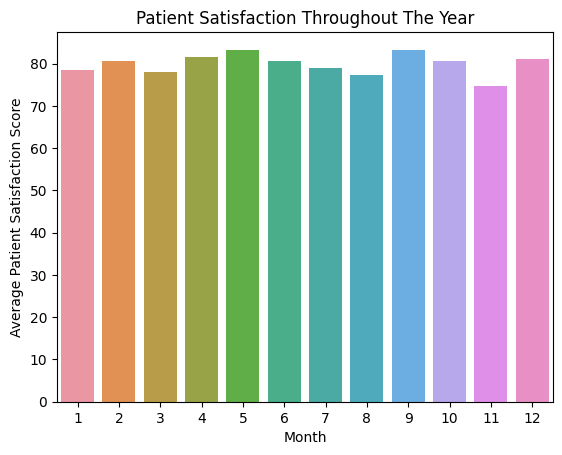

In [16]:
sns.barplot(x=monthly_average_satisfaction_scores.index, y=monthly_average_satisfaction_scores.values)
plt.title("Patient Satisfaction Throughout The Year")
plt.xlabel("Month")
plt.ylabel("Average Patient Satisfaction Score")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

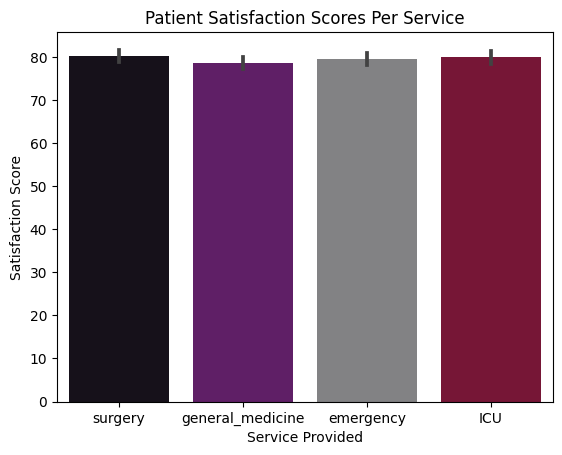

In [17]:
sns.barplot(data=patients, x='service', y='satisfaction', palette=dark_seaborn_palette)
plt.title("Patient Satisfaction Scores Per Service")
plt.xlabel("Service Provided")
plt.ylabel("Satisfaction Score")
plt.show

In [18]:
attendance_rate= schedule.groupby('service')['present'].mean()
attendance_rate

service
ICU                 0.601244
emergency           0.604043
general_medicine    0.589973
surgery             0.602308
Name: present, dtype: float64

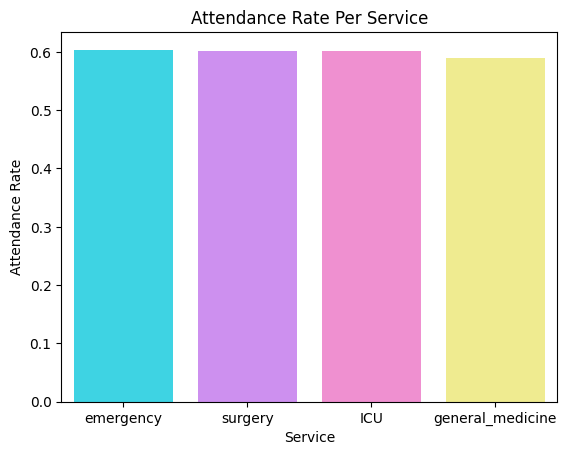

In [19]:
attendance_rate = schedule.groupby('service')['present'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=attendance_rate, x='service', y='present',palette=pastel_seaborn_palette)
plt.title('Attendance Rate Per Service')
plt.xlabel('Service')
plt.ylabel('Attendance Rate')
plt.show()

In [20]:
weekly_attendances= schedule.groupby('week')['present'].mean()
weekly_attendances

week
1     0.920635
2     0.912698
3     0.000000
4     0.849206
5     0.857143
6     0.000000
7     0.912698
8     0.865079
9     0.000000
10    0.888889
11    0.873016
12    0.000000
13    0.849206
14    0.825397
15    0.000000
16    0.896825
17    0.873016
18    0.000000
19    0.936508
20    0.912698
21    0.000000
22    0.912698
23    0.928571
24    0.000000
25    0.880952
26    0.944444
27    0.000000
28    0.920635
29    0.912698
30    0.000000
31    0.857143
32    0.880952
33    0.000000
34    0.888889
35    0.865079
36    0.000000
37    0.880952
38    0.920635
39    0.000000
40    0.873016
41    0.936508
42    0.000000
43    0.888889
44    0.888889
45    0.000000
46    0.865079
47    0.888889
48    0.000000
49    0.936508
50    0.888889
51    0.000000
52    0.857143
Name: present, dtype: float64

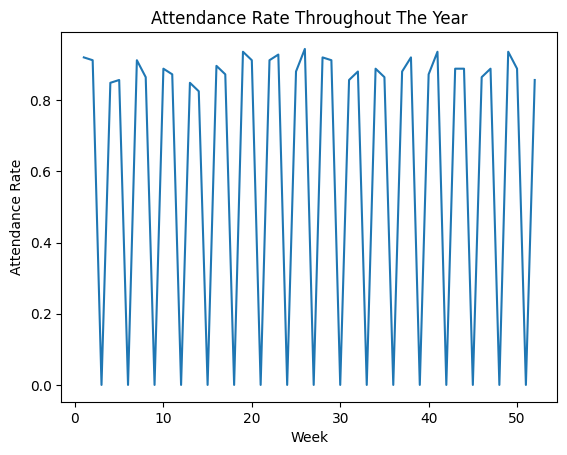

In [21]:
weekly_attendances = schedule.groupby('week')['present'].mean().sort_values(ascending=False).reset_index()
sns.lineplot(data=weekly_attendances, x='week', y='present',palette=dark_seaborn_palette)
plt.title('Attendance Rate Throughout The Year')
plt.xlabel('Week')
plt.ylabel('Attendance Rate')
plt.show()

In [22]:
admission_rate_service=services.groupby('service')[['patients_admitted','patients_request']].sum()
admission_rate_service

,patients_admitted,patients_request
service,,
ICU,648,789
emergency,1185,6193
general_medicine,2332,4270
surgery,1686,2241


In [23]:
admission_rate_service['admission_rate']=(admission_rate_service['patients_admitted']/admission_rate_service['patients_request'])
admission_rate_service= admission_rate_service['admission_rate']
admission_rate_service

service
ICU                 0.821293
emergency           0.191345
general_medicine    0.546136
surgery             0.752343
Name: admission_rate, dtype: float64

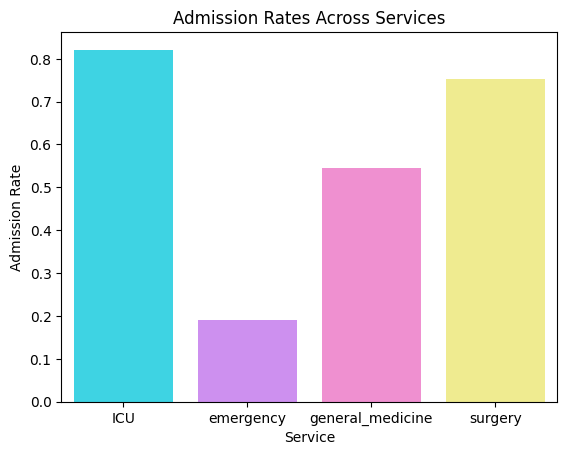

In [24]:
sns.barplot(x= admission_rate_service.index, y=admission_rate_service.values, palette=pastel_seaborn_palette)
plt.title('Admission Rates Across Services')
plt.xlabel('Service')
plt.ylabel('Admission Rate')
plt.show()

In [25]:
refusal_rate_service=services.groupby('service')[['patients_refused','patients_request']].sum()
refusal_rate_service

,patients_refused,patients_request
service,,
ICU,141,789
emergency,5008,6193
general_medicine,1938,4270
surgery,555,2241


In [26]:
refusal_rate_service['refusal_rate']=(refusal_rate_service['patients_refused']/refusal_rate_service['patients_request'])
refusal_rate_service= refusal_rate_service['refusal_rate']
refusal_rate_service

service
ICU                 0.178707
emergency           0.808655
general_medicine    0.453864
surgery             0.247657
Name: refusal_rate, dtype: float64

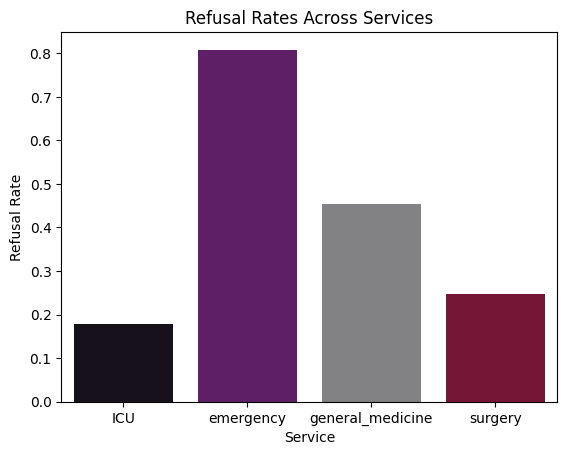

In [27]:
sns.barplot(x= refusal_rate_service.index, y=refusal_rate_service.values,palette=dark_seaborn_palette)
plt.title('Refusal Rates Across Services')
plt.xlabel('Service')
plt.ylabel('Refusal Rate')
plt.show()

In [28]:
monthly_service_requests= services.groupby(['month','service'])['patients_request'].sum()
monthly_service_requests

month  service         
1      ICU                   80
       emergency            579
       general_medicine     594
       surgery              279
2      ICU                   82
       emergency            953
       general_medicine     378
       surgery              194
3      ICU                   58
       emergency            687
       general_medicine     261
       surgery              170
4      ICU                   54
       emergency            436
       general_medicine     339
       surgery              255
5      ICU                   57
       emergency            348
       general_medicine     231
       surgery              142
6      ICU                   36
       emergency            383
       general_medicine     253
       surgery              129
7      ICU                   32
       emergency            280
       general_medicine     220
       surgery              121
8      ICU                   49
       emergency            314
       general_m

In [29]:
monthly_service_requests= services.groupby(['month','service'])['patients_request'].sum().reset_index()

<function matplotlib.pyplot.show(close=None, block=None)>

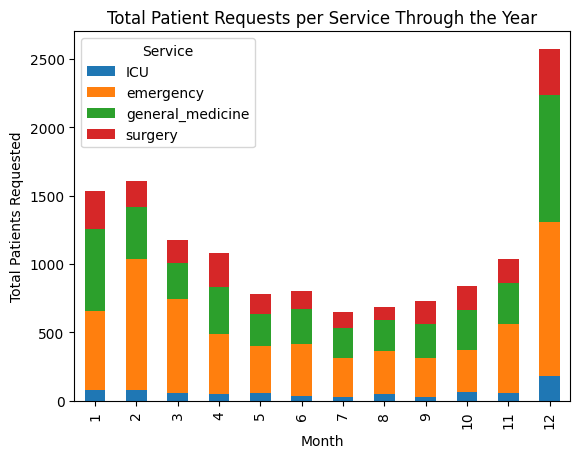

In [30]:
pivoted=monthly_service_requests.pivot(index='month', columns='service', values='patients_request')
pivoted.plot(kind='bar', stacked=True,)
plt.title('Total Patient Requests per Service Through the Year')
plt.xlabel('Month')
plt.ylabel('Total Patients Requested')
plt.legend(title='Service')
plt.show

In [31]:
satisfaction_rate_service=services.groupby('service')['patient_satisfaction'].mean()
satisfaction_rate_service

service
ICU                 81.615385
emergency           77.884615
general_medicine    81.230769
surgery             79.269231
Name: patient_satisfaction, dtype: float64

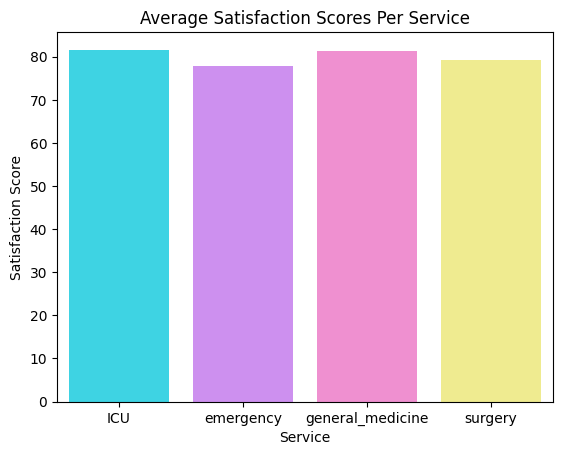

In [32]:
sns.barplot(x= satisfaction_rate_service.index, y=satisfaction_rate_service.values,palette=pastel_seaborn_palette)
plt.title('Average Satisfaction Scores Per Service')
plt.xlabel('Service')
plt.ylabel('Satisfaction Score')
plt.show()

In [33]:
bed_availability_per_service= services.groupby('service')['available_beds'].mean()
bed_availability_per_service

service
ICU                 14.846154
emergency           22.788462
general_medicine    46.230769
surgery             37.519231
Name: available_beds, dtype: float64

# CONCLUSIONS

To answer the first question, satisfaction score rates seem to neither increase nor decrease. Instead, they maintain a steady 85% rate, with those being the highest for the ICU service. Factors that may contribute to these may be that its admission rates are highest (and its refusal rates being the lowest), though its staff attendance rate is roughly the same as the emergency and surgery services. The service that seems to be affected most by these factors is most likely the emergency service as it generally has a slightly lower satisfaction score and a significantly higher refusal rate than the other three services, though it appears to have more available beds on average than the ICU ones. This is most likely because the ICU has the lowest demand and is probably a higher priority service, and staff may need to be allocated to accomodate for it.